# Baseline 224x224 CNN Report

This notebook documents the 224x224 rerun of the baseline CNN. It uses the same `small_cnn` architecture as the 28x28 baseline, trained from scratch on the official 224x224 PathMNIST images. The checkpoint and predictions are stored in `models/baseline_224` and `results/baseline_224`.

The run used the baseline training recipe with histology augmentation, AdamW, cosine learning-rate scheduling, label smoothing, and light MixUp. The batch size was reduced from the 28x28 baseline's 512 to 32 because the 224x224 tensors did not fit reliably on local MPS at larger batch sizes. The selected checkpoint is epoch 10, chosen by the existing baseline rule `validation ROC-AUC + validation accuracy`, not by test labels.

Training runtime was 6.23 hours on local MPS. The final test result for colorectal adenocarcinoma epithelium F2 is **0.962267**. The final test result for cancer-associated stroma F2 is **0.568831**.


## Test Metrics

| Metric | Test value |
|---|---:|
| Accuracy | 0.905710 |
| ROC-AUC | 0.993470 |
| Macro precision | 0.900499 |
| Macro recall | 0.888587 |
| Macro specificity | 0.988199 |
| Macro F1 | 0.884590 |
| Macro F2 | 0.885024 |
| Colorectal adenocarcinoma epithelium precision | 0.869472 |
| Colorectal adenocarcinoma epithelium recall | 0.988646 |
| Colorectal adenocarcinoma epithelium specificity | 0.969228 |
| Colorectal adenocarcinoma epithelium F1 | 0.925237 |
| Colorectal adenocarcinoma epithelium F2 | 0.962267 |
| Cancer-associated stroma precision | 0.908714 |
| Cancer-associated stroma recall | 0.520190 |
| Cancer-associated stroma specificity | 0.996745 |
| Cancer-associated stroma F1 | 0.661631 |
| Cancer-associated stroma F2 | 0.568831 |

The 224x224 model has strong colorectal adenocarcinoma epithelium recall on the test split, but it still struggles with cancer-associated stroma. For stroma, the dominant issue is false negatives: only 219 of 421 true stroma samples are classified as stroma, while 77 are classified as colorectal adenocarcinoma epithelium and 78 as smooth muscle.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

RESULT_DIR = Path('../results/baseline_224')
MODEL_DIR = Path('../models/baseline_224')
FIG_DIR = Path('../report/figures')

metrics = json.loads((RESULT_DIR / 'metrics.json').read_text())
config = json.loads((MODEL_DIR / 'config.json').read_text())
cm = np.array(metrics['test']['confusion_matrix'])

print('Selected epoch:', metrics['best_epoch'])
print('Training hours:', metrics['seconds'] / 3600)
print('Model parameters:', config['parameters'])
print('Device:', config['device_resolved'])
print('Batch size:', config['batch_size'])

Selected epoch: 10
Training hours: 6.225290109448963
Model parameters: 558921
Device: mps
Batch size: 32


In [3]:
def one_vs_rest_metrics(confusion_matrix, class_index, beta=2):
    tp = float(confusion_matrix[class_index, class_index])
    fp = float(confusion_matrix[:, class_index].sum() - tp)
    fn = float(confusion_matrix[class_index, :].sum() - tp)
    tn = float(confusion_matrix.sum() - tp - fp - fn)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    beta_squared = beta ** 2
    fbeta = (1 + beta_squared) * precision * recall / (beta_squared * precision + recall) if beta_squared * precision + recall else 0.0
    return {
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'f2': fbeta,
        'support': int(confusion_matrix[class_index].sum()),
    }

rows = {
    'cancer-associated stroma': one_vs_rest_metrics(cm, 7),
    'colorectal adenocarcinoma epithelium': one_vs_rest_metrics(cm, 8),
}
pd.DataFrame(rows).T

,precision,recall,specificity,f1,f2,support
cancer-associated stroma,0.908714,0.520190,0.996745,0.661631,0.568831,421.0
colorectal adenocarcinoma epithelium,0.869472,0.988646,0.969228,0.925237,0.962267,1233.0


## Confusion Matrix

The matrix below is the final test confusion matrix for the selected 224x224 baseline checkpoint. Rows are true labels and columns are predicted labels.

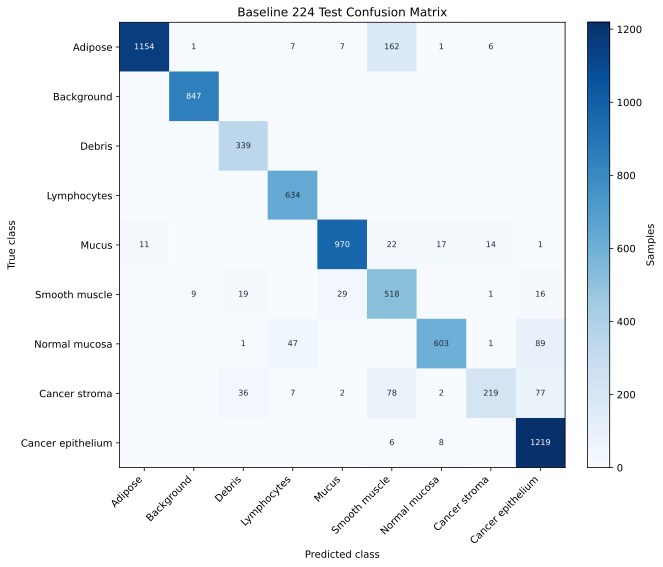

In [4]:
from IPython.display import SVG, display

display(SVG(filename=str(FIG_DIR / 'baseline224_confusion_matrix.svg')))

## Layer-Level Feature Maps

The baseline CNN predicts by transforming the image through three convolutional stages and then applying global average pooling and a linear classifier. Early maps mostly respond to color and local texture contrast. Mid-level maps collect recurring tissue structures. Late maps are the most class-specific because they are immediately upstream of the global pooling and classifier head.

For the visualization below, the notebook uses a correctly classified colorectal adenocarcinoma epithelium test image and displays the eight highest-mean activation channels from three representative layers: `net[2]`, `net[9]`, and `net[16]`. These feature maps are not direct human-labeled morphology concepts, but they show where the model has built strong internal responses at each depth.

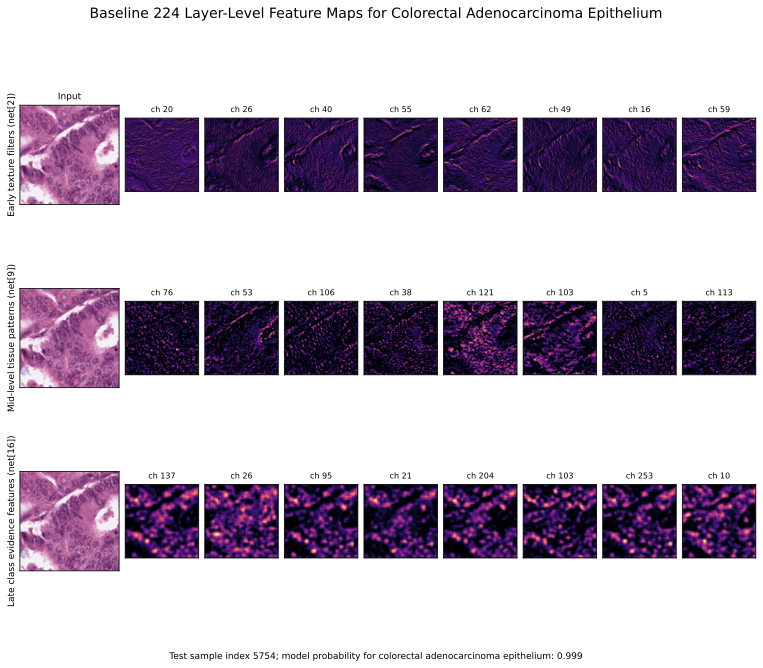

In [5]:
display(SVG(filename=str(FIG_DIR / 'baseline224_cancer_feature_maps.svg')))

## Grad-CAM

Grad-CAM uses the gradient of the colorectal adenocarcinoma epithelium logit with respect to the final convolutional activation map. Channels whose gradients increase the target class are weighted more strongly, producing a heatmap over the image. The figure uses test sample index 5754, the same cancer datapoint used for the generated Grad-CAM artifact, and shows the input image, standalone heatmap, and tissue-region overlay.

This is an interpretability aid, not a proof that the model uses clinically correct evidence. It is most useful when compared across correct predictions, false positives, and false negatives.


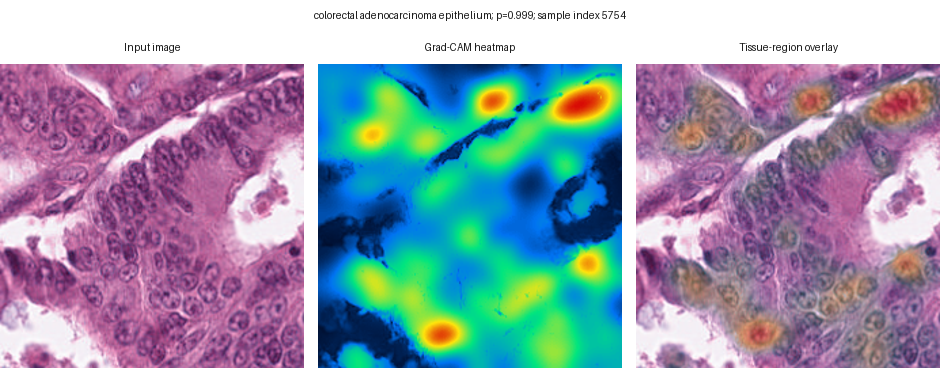

In [6]:
display(SVG(filename=str(FIG_DIR / 'baseline224_cancer_gradcam.svg')))

## Reproducibility Notes

The full training command was:

```bash
PYTHONPATH=src .venv/bin/python -m pathmnist.train \
  --model small_cnn \
  --image-size 224 \
  --source-size 224 \
  --augment histology \
  --epochs 10 \
  --batch-size 32 \
  --lr 0.001 \
  --weight-decay 0.0001 \
  --optimizer adamw \
  --scheduler cosine \
  --label-smoothing 0.03 \
  --mixup-alpha 0.05 \
  --class-weights none \
  --seed 42 \
  --workers 0 \
  --device auto \
  --data-root data \
  --norm pathmnist \
  --results-dir results \
  --models-dir models \
  --run-name baseline_224 \
  --target-cancer-f2 0.98 \
  --no-progress
```

Artifacts needed to reconstruct the reported values:

- `models/baseline_224/best.pt`: selected model checkpoint.
- `models/baseline_224/config.json`: model and training configuration.
- `results/baseline_224/history.json`: per-epoch validation history.
- `results/baseline_224/val_predictions.npz`: selected-checkpoint validation predictions.
- `results/baseline_224/test_predictions.npz`: selected-checkpoint test predictions.
- `results/baseline_224/metrics.json`: final validation and test metrics.
